In [1]:
import os
import cv2

import numpy as np
import pandas as pd
np.set_printoptions(suppress=True)

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import LinearLocator
%matplotlib inline

In [2]:
plt.rcParams['figure.figsize'] = ((8/2.54), (6/2.54))
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.default"] = "rm"
plt.rcParams.update({'font.size': 11})
MARKER_SIZE = 15
cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

plt.rcParams['axes.spines.top'] = False
# plt.rcParams['axes.edgecolor'] = 
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

In [3]:
MASTER_DIRECTORY = './images/'
file_list = os.listdir(MASTER_DIRECTORY)
dir_list = [file for file in file_list if file.startswith('LAI2')]
dir_list.sort()

In [5]:
green_value = []
for DIRECTORY in dir_list:
    print(DIRECTORY)
    file_list = os.listdir(MASTER_DIRECTORY + DIRECTORY)
    dataset_list = [file for file in file_list if file.endswith('.jpg')]
    dataset_list.sort()
    process = 0
    for FILENAME in dataset_list:
        if process % 500 == 0:
            print(FILENAME)
        process += 1
        img = cv2.imread('%s/%s' % (MASTER_DIRECTORY + DIRECTORY, FILENAME), 1)
        if type(img) == type(None):
            break
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        lower_green = np.array([55, 80, 40])
        upper_green = np.array([85, 255, 255])

        mask = cv2.inRange(hsv, lower_green, upper_green)    
        result = cv2.bitwise_and(img, img, mask=mask)  
        green_value.append(result[result > 0].shape[0])

LAI2_OVER_20200501-0504
frame_0001.jpg
LAI2_OVER_20200504-0511
frame_0000.jpg
frame_0500.jpg
frame_1000.jpg
LAI2_OVER_20200511-0518
frame_0000.jpg
frame_0500.jpg
LAI2_OVER_20200518-0525
frame_0000.jpg
frame_0500.jpg
frame_1000.jpg
LAI2_OVER_20200525-0601
frame_0000.jpg
frame_0500.jpg
frame_1000.jpg
LAI2_OVER_20200601-0610
frame_0000.jpg
frame_0500.jpg
frame_1000.jpg


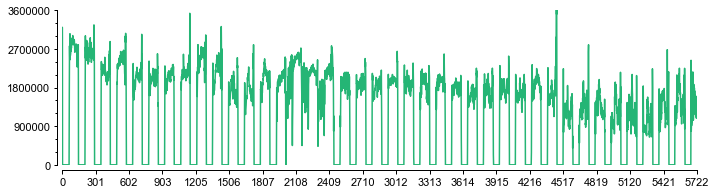

In [6]:
fig = plt.figure(figsize=((8/2.54*3.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(np.arange(len(green_value)), green_value, c=cmap[3])

ax0.set_ybound(0, 3600000)
ax0.set_xbound(0, len(green_value))

ax0.xaxis.set_major_locator(LinearLocator(20))
ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(13))

fig.tight_layout()
plt.show() 

In [7]:
pd.Series(np.array(green_value)).to_csv('./results/green_pixels_lai2.csv')

/home/ubuntu/anaconda3/envs/tensorflow2_p36/lib/python3.6/site-packages/ipykernel/__main__.py:1: FutureWarning: The signature of `Series.to_csv` was aligned to that of `DataFrame.to_csv`, and argument 'header' will change its default value from False to True: please pass an explicit value to suppress this warning.
  if __name__ == '__main__':
